In [1]:
import pm4py
import pandas as pd
import numpy as np
from pm4py.visualization.footprints import visualizer as fp_visualizer
from pm4py.algo.discovery.footprints import algorithm as footprints_discovery
from pm4py.algo.evaluation.replay_fitness import algorithm as replay_fitness_evaluator
from pm4py.algo.evaluation.precision import algorithm as precision_evaluator
from pm4py.algo.evaluation.simplicity import algorithm as simplicity_evaluator
from pm4py.algo.evaluation.generalization import algorithm as generalization_evaluator

In [2]:
log = pm4py.read_xes("../data/BPI Challenge 2017.xes.gz")

/Users/felixhauptmann/ProM-Assignment-Group-C/.venv/lib/python3.13/site-packages/pm4py/utils.py:1027: UserWarning: Install the optional requirement `r4pm` to import/export files faster. `rustxes` remains supported as a fallback.
  warnings.warn(


parsing log, completed traces ::   0%|          | 0/31509 [00:00<?, ?it/s]

In [3]:
log_noised = pm4py.read_xes("../data/noised.xes.gz")

parsing log, completed traces ::   0%|          | 0/31509 [00:00<?, ?it/s]

In [4]:
log_recovered = pm4py.read_xes("../data/recovered.xes.gz")

parsing log, completed traces ::   0%|          | 0/31509 [00:00<?, ?it/s]

In [5]:
df = pm4py.convert_to_dataframe(log)
df_noised = pm4py.convert_to_dataframe(log_noised)
df_recovered = pm4py.convert_to_dataframe(log_recovered)

In [29]:
dfg, start_activities, end_activities = pm4py.discover_dfg(log)
dfg_noised, start_activities_noised, end_activities_noised = pm4py.discover_dfg(log_noised)
dfg_recovered, start_activities_recovered, end_activities_recovered = pm4py.discover_dfg(log_recovered)

## a) Footprint Matrix

### 1. Clean log

In [6]:
footprints = footprints_discovery.apply(log)

In [7]:
footprints["sequence"]

{('A_Accepted', 'O_Create Offer'),
 ('A_Complete', 'A_Cancelled'),
 ('A_Complete', 'A_Denied'),
 ('A_Complete', 'O_Cancelled'),
 ('A_Complete', 'O_Create Offer'),
 ('A_Complete', 'O_Sent (mail and online)'),
 ('A_Complete', 'O_Sent (online only)'),
 ('A_Complete', 'W_Shortened completion '),
 ('A_Concept', 'A_Accepted'),
 ('A_Concept', 'W_Shortened completion '),
 ('A_Create Application', 'A_Concept'),
 ('A_Create Application', 'A_Submitted'),
 ('A_Create Application', 'W_Complete application'),
 ('A_Denied', 'O_Refused'),
 ('A_Incomplete', 'A_Denied'),
 ('A_Incomplete', 'O_Accepted'),
 ('A_Incomplete', 'O_Create Offer'),
 ('A_Incomplete', 'O_Returned'),
 ('A_Incomplete', 'W_Shortened completion '),
 ('A_Pending', 'W_Call after offers'),
 ('A_Pending', 'W_Call incomplete files'),
 ('A_Pending', 'W_Validate application'),
 ('A_Submitted', 'W_Handle leads'),
 ('A_Validating', 'A_Cancelled'),
 ('A_Validating', 'A_Denied'),
 ('A_Validating', 'O_Accepted'),
 ('A_Validating', 'O_Create Offer

In [8]:
footprints["parallel"]

{('A_Accepted', 'W_Complete application'),
 ('A_Accepted', 'W_Shortened completion '),
 ('A_Cancelled', 'O_Cancelled'),
 ('A_Cancelled', 'W_Call after offers'),
 ('A_Cancelled', 'W_Call incomplete files'),
 ('A_Cancelled', 'W_Complete application'),
 ('A_Cancelled', 'W_Validate application'),
 ('A_Complete', 'W_Call after offers'),
 ('A_Concept', 'W_Complete application'),
 ('A_Denied', 'W_Call after offers'),
 ('A_Denied', 'W_Call incomplete files'),
 ('A_Denied', 'W_Complete application'),
 ('A_Denied', 'W_Validate application'),
 ('A_Incomplete', 'W_Call incomplete files'),
 ('A_Validating', 'W_Validate application'),
 ('O_Cancelled', 'A_Cancelled'),
 ('O_Cancelled', 'O_Cancelled'),
 ('O_Cancelled', 'O_Returned'),
 ('O_Cancelled', 'O_Sent (mail and online)'),
 ('O_Cancelled', 'O_Sent (online only)'),
 ('O_Cancelled', 'W_Call after offers'),
 ('O_Cancelled', 'W_Call incomplete files'),
 ('O_Cancelled', 'W_Complete application'),
 ('O_Cancelled', 'W_Validate application'),
 ('O_Create

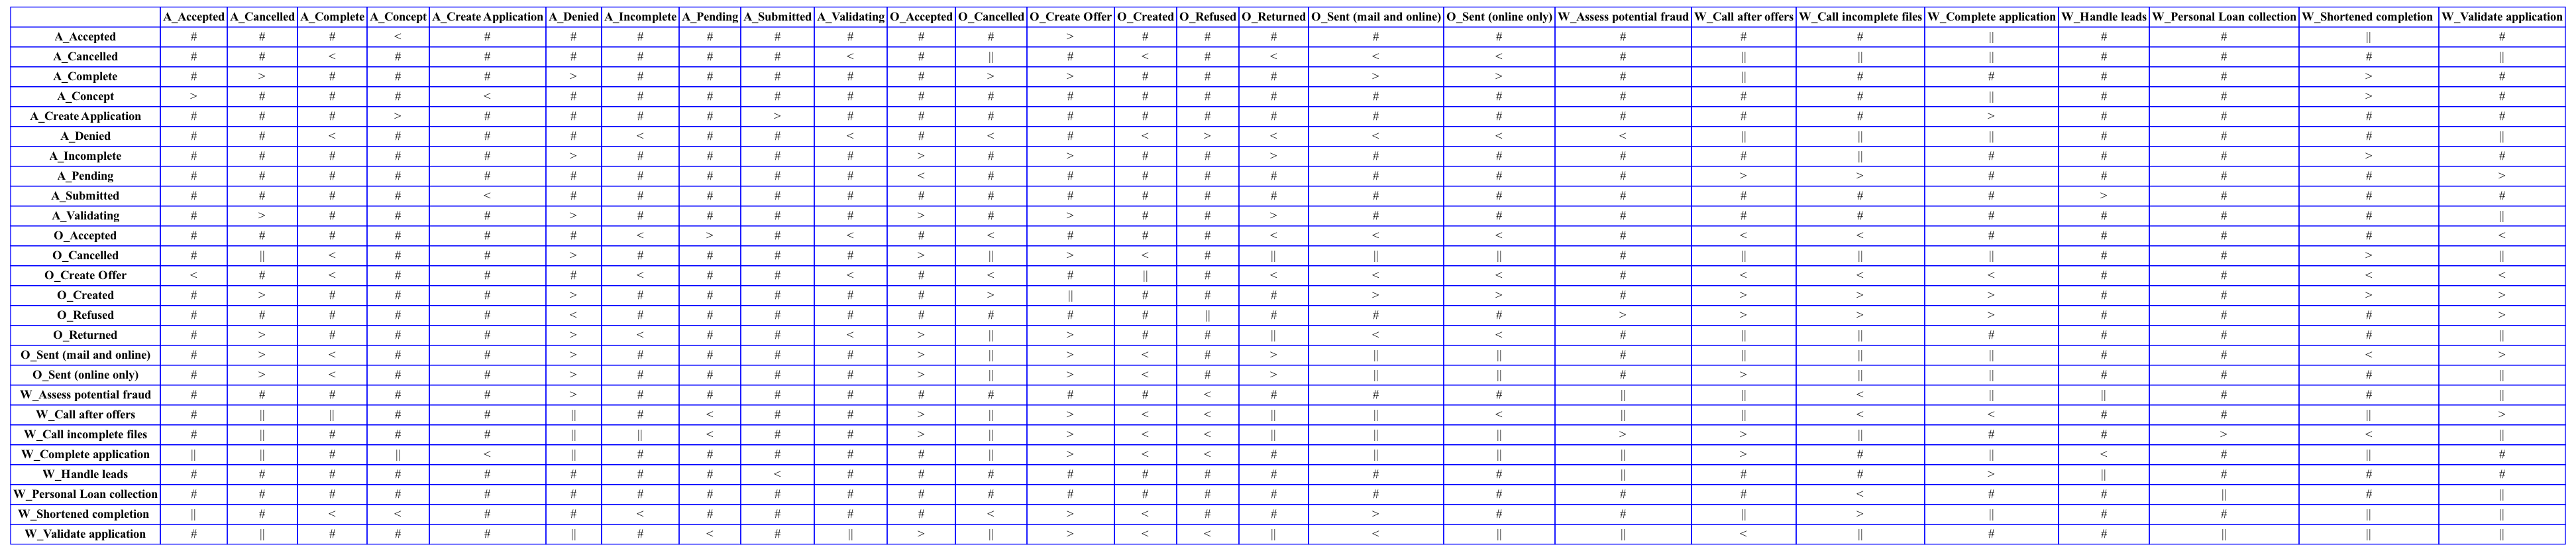

In [9]:
gviz_footprints = fp_visualizer.apply(footprints)
fp_visualizer.view(gviz_footprints)

### Specific Trace

Confirms Footprint Matrix:

**Example for sequence (< / >):**

A_Create Application > A_Submitted

A_Submitted < A_Create Application

**Example for parallel (||):**

A_Complete || W_Call after offers

W_Call after offers || A_Complete

**Example for no relation (#):**

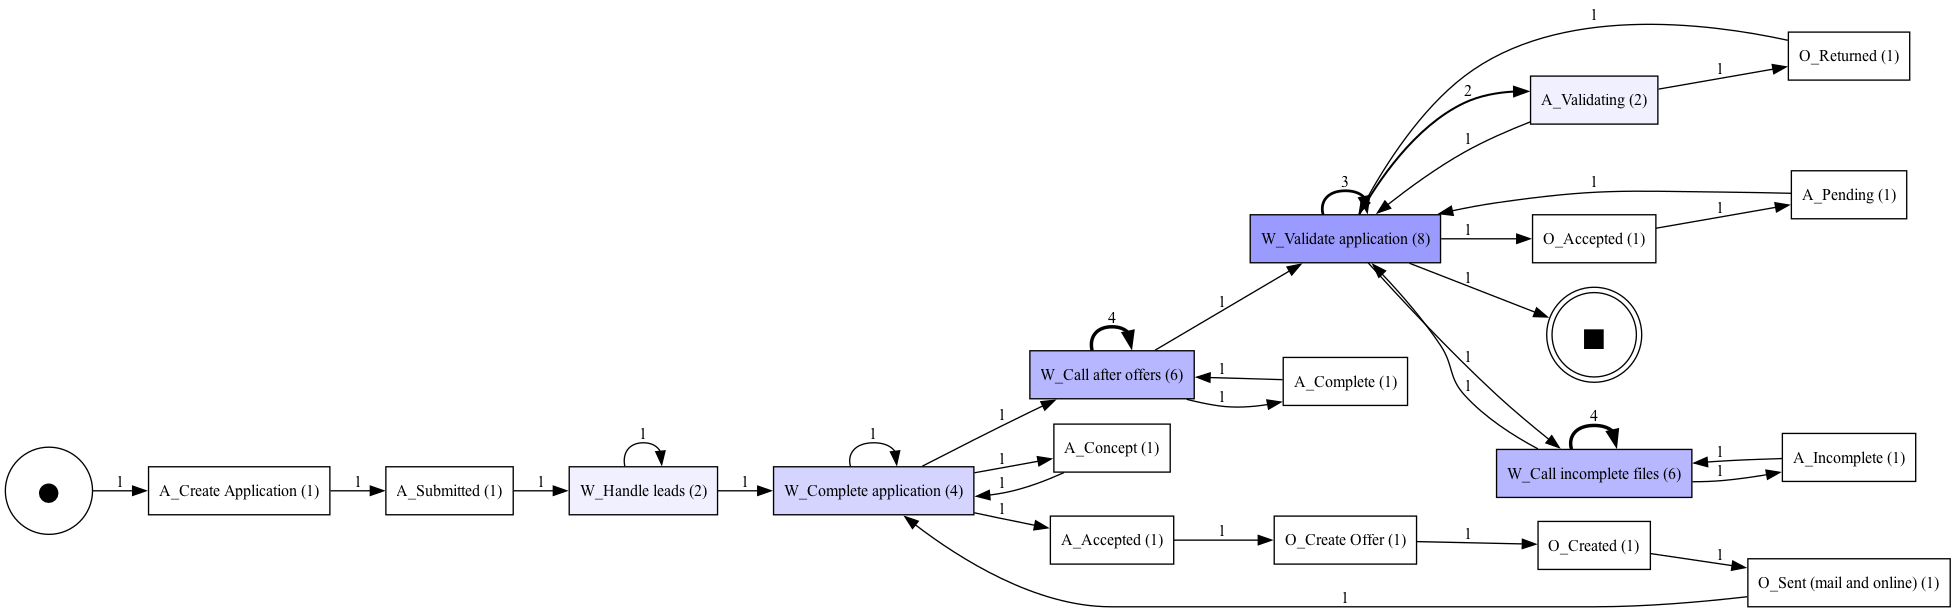

In [35]:
case_list = list(df['case:concept:name'].unique())
dfg_trace, start_activities_trace, end_activities_trace = pm4py.discover_dfg(df[df['case:concept:name'].isin(case_list[:1])])
pm4py.view_dfg(dfg_trace, start_activities, end_activities)

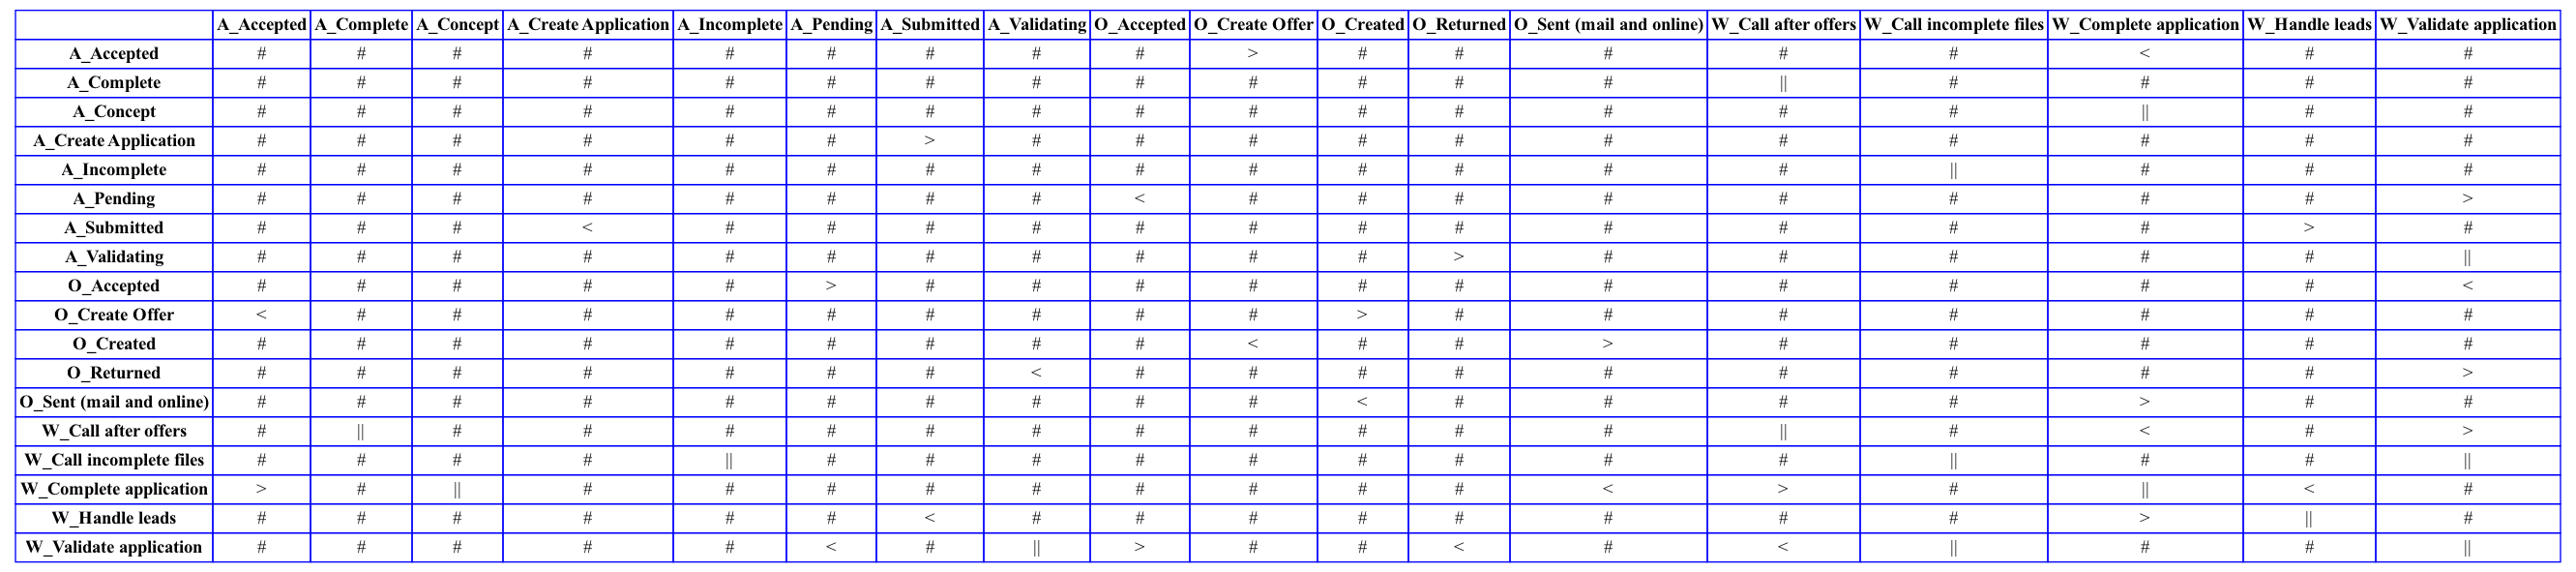

In [36]:
footprints_trace = footprints_discovery.apply(df[df['case:concept:name'].isin(case_list[:1])])
gviz_footprints_trace = fp_visualizer.apply(footprints_trace)
fp_visualizer.view(gviz_footprints_trace)

In [30]:
#('A_Create Application', 'A_Submitted') from sequence list
print(dfg.get(("A_Create Application", "A_Submitted"), 0))
print(dfg.get(("A_Submitted", "A_Create Application"), 0))

20423
0


In [37]:
# ('A_Complete', 'W_Call after offers')
print(dfg.get(("A_Complete", "W_Call after offers"), 0))
print(dfg.get(("W_Call after offers", "A_Complete"), 0))

30396
31362


In [44]:
# get activities from first trace

case_id = case_list[0]

trace_df = df[df["case:concept:name"] == case_id]

trace_activities = trace_df["concept:name"].tolist()

trace_activities

['A_Create Application',
 'A_Submitted',
 'W_Handle leads',
 'W_Handle leads',
 'W_Complete application',
 'A_Concept',
 'W_Complete application',
 'W_Complete application',
 'A_Accepted',
 'O_Create Offer',
 'O_Created',
 'O_Sent (mail and online)',
 'W_Complete application',
 'W_Call after offers',
 'W_Call after offers',
 'A_Complete',
 'W_Call after offers',
 'W_Call after offers',
 'W_Call after offers',
 'W_Call after offers',
 'W_Validate application',
 'W_Validate application',
 'A_Validating',
 'O_Returned',
 'W_Validate application',
 'W_Validate application',
 'W_Call incomplete files',
 'W_Call incomplete files',
 'A_Incomplete',
 'W_Call incomplete files',
 'W_Call incomplete files',
 'W_Call incomplete files',
 'W_Call incomplete files',
 'W_Validate application',
 'W_Validate application',
 'A_Validating',
 'W_Validate application',
 'O_Accepted',
 'A_Pending',
 'W_Validate application']

In [45]:
# find activities with no relation
def find_hash_relation_example(dfg, activities):
    for a in activities:
        for b in activities:
            if a == b:
                continue

            if dfg.get((a, b), 0) == 0 and dfg.get((b, a), 0) == 0:
                return a, b

    return None

In [46]:
find_hash_relation_example(dfg_trace, trace_activities)

('A_Create Application', 'W_Handle leads')

In [48]:
print(dfg.get(("A_Create Application", "W_Handle leads"), 0))
print(dfg.get(("W_Handle leads", "A_Create Application"), 0))

0
0


### 2. Noised Log

In [52]:
footprints_noised = footprints_discovery.apply(log_noised)

In [53]:
footprints_noised["sequence"]

{('W_Handle leads - Incident No. Application_455007935',
  'W_Complete application'),
 ('O_Ret.', 'A_Den.'),
 ('O_Acc.', 'A_Pending'),
 ('W_Call after offers - Incident No. Application_1213956619',
  'W_Call after offers'),
 ('W_Call after ofrs.', 'O_Returned - Incident No. Application_1036485758'),
 ('W_Complete application - Incident No. Application_1099430757',
  'W_Complete appl.'),
 ('O_Sent (mail and online)',
  'W_Call after offers - Incident No. Application_1634183264'),
 ('O_Sent (mail and onl.)', 'W_Call incompl. files'),
 ('A_Create Application - Incident No. Application_83386929',
  'W_Complete appl.'),
 ('A_Subm. - Incident No. Application_1674907586', 'W_Handle leads'),
 ('W_Complete application - Incident No. Application_112954315',
  'W_Finish application'),
 ('O_Sent (mail and onl.)', 'W_Call after ofrs.'),
 ('W_Call after offers',
  'W_Call after offers - Incident No. Application_393911084'),
 ('W_Complete application - Incident No. Application_1292199013',
  'W_Call 

In [54]:
footprints_noised["parallel"]

{('A_Acc.', 'W_Complete appl.'),
 ('A_Acc.', 'W_Complete application'),
 ('A_Acc.', 'W_Finalize application'),
 ('A_Acc.', 'W_Finish application'),
 ('A_Acc.', 'W_Shortened completion '),
 ('A_Accepted', 'W_Complete appl.'),
 ('A_Accepted', 'W_Complete application'),
 ('A_Accepted', 'W_Finalize application'),
 ('A_Accepted', 'W_Finish application'),
 ('A_Accepted', 'W_Shortened completion '),
 ('A_Canc.', 'O_Cancelled'),
 ('A_Canc.', 'W_Call after offers'),
 ('A_Canc.', 'W_Call incomplete files'),
 ('A_Canc.', 'W_Complete application'),
 ('A_Cancelled', 'O_Canc.'),
 ('A_Cancelled', 'O_Cancelled'),
 ('A_Cancelled', 'W_Call after offers'),
 ('A_Cancelled', 'W_Call after ofrs.'),
 ('A_Cancelled', 'W_Call incompl. files'),
 ('A_Cancelled', 'W_Call incomplete files'),
 ('A_Cancelled', 'W_Complete application'),
 ('A_Cancelled', 'W_Finalize application'),
 ('A_Cancelled', 'W_Finish application'),
 ('A_Comp.', 'W_Call after offers'),
 ('A_Comp.', 'W_Call after ofrs.'),
 ('A_Comp. - Incident N

In [55]:
gviz_footprints_noised = fp_visualizer.apply(footprints_noised)
fp_visualizer.view(gviz_footprints_noised)

dot: graph is too large for cairo-renderer bitmaps. Scaling by 0.0744092 to fit


#### Specific Trace

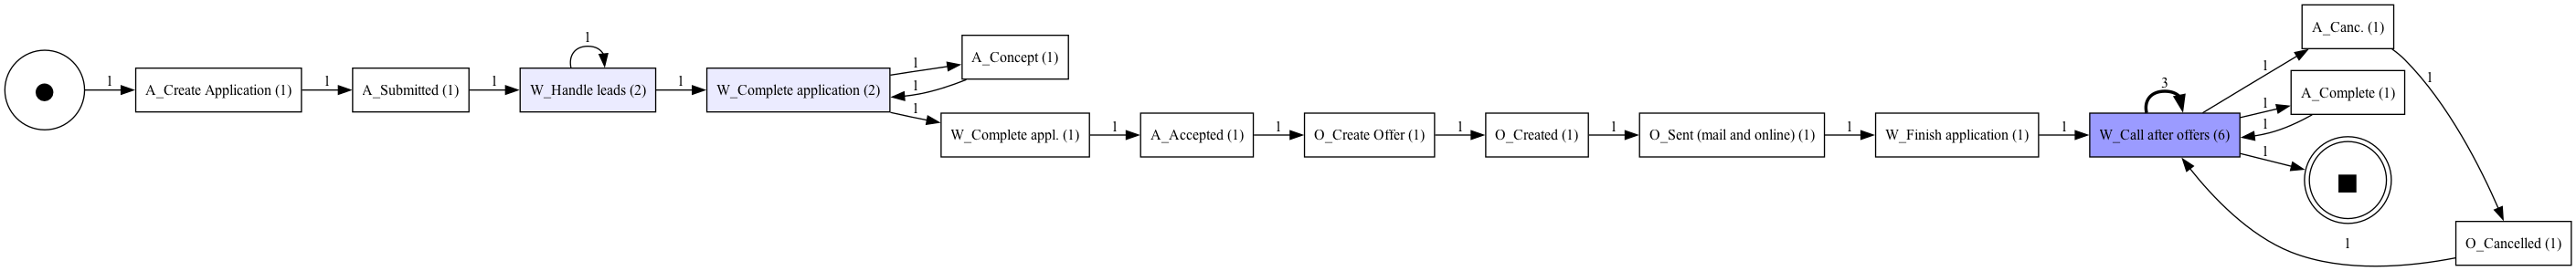

In [65]:
case_list_noised = list(df_noised['case:concept:name'].unique())
dfg_trace_noised, start_activities_trace_noised, end_activities_trace_noised = pm4py.discover_dfg(df_noised[df_noised['case:concept:name'].isin(case_list[:1])])
pm4py.view_dfg(dfg_trace_noised, start_activities_trace_noised, end_activities_trace_noised)

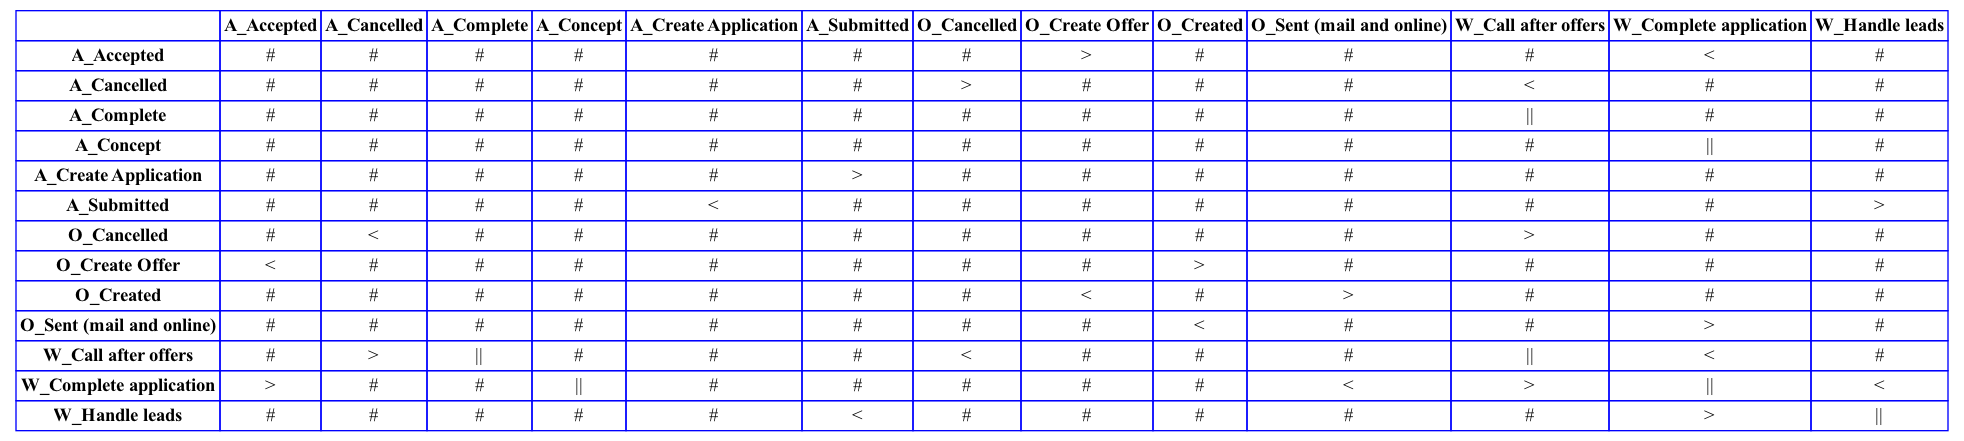

In [67]:
footprints_trace_noised = footprints_discovery.apply(df[df['case:concept:name'].isin(case_list_noised[:1])])
gviz_footprints_trace_noised = fp_visualizer.apply(footprints_trace_noised)
fp_visualizer.view(gviz_footprints_trace_noised)